Data: [Kaggle](https://github.com/Doug-Vo/ML-Self-Project/pull/new/MSP-1_Set_up_doc)


In [1]:
# !pip install kneed

In [2]:

# import kagglehub
# path = kagglehub.dataset_download('uom190346a/sleep-health-and-lifestyle-dataset')

# print('Data source import complete.')

# import matplotlib.pyplot as plt
# import seaborn as sns

# import warnings
# import sys
# if not sys.warnoptions:
#     warnings.simplefilter("ignore")
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use('ggplot')

import warnings
warnings.filterwarnings("ignore")

# df = pd.read_csv(f'{path}/Sleep_health_and_lifestyle_dataset.csv')

df = pd.read_csv('data/sleep_health.csv')
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## EDA & Preprocessing



In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 49.2 KB


In [5]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [6]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Sleep Disorder'].unique()

<ArrowStringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

In [9]:
df['BMI Category'].unique()

<ArrowStringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str

In [10]:
df.groupby("BMI Category").agg(
    count = ("Person ID", "count"),
    avg_age=("Age", "mean"),
    avg_sleep_duration=("Sleep Duration", "mean"),
    avg_sleep_quality=("Quality of Sleep", "mean"),
    avg_stress=("Stress Level", "mean"),
    avg_heart_rate=("Heart Rate", "mean"),
)



,count,avg_age,avg_sleep_duration,avg_sleep_quality,avg_stress,avg_heart_rate
BMI Category,,,,,,
Normal,195,38.482051,7.393846,7.661538,5.128205,68.728205
Normal Weight,21,38.380952,7.333333,7.428571,5.190476,71.285714
Obese,10,38.000000,6.960000,6.400000,5.700000,84.300000
Overweight,148,47.885135,6.770270,6.898649,5.729730,70.945946


In [11]:
from scipy.stats import ttest_ind

normal = df[df["BMI Category"] == "Normal"]["Quality of Sleep"]
normal_weight = df[df["BMI Category"] == "Normal Weight"]["Quality of Sleep"];'f[rt5]'

ttest_ind(normal, normal_weight, nan_policy="omit")


TtestResult(statistic=np.float64(1.0172112052956301), pvalue=np.float64(0.31020160099503685), df=np.float64(214.0))

In [12]:
bmi_mapping = {
    'Normal' : 0,
    'Normal Weight': 0,
    'Overweight': 1,
    'Obese': 2
}

df['BMI Category'] = df['BMI Category'].map(bmi_mapping)

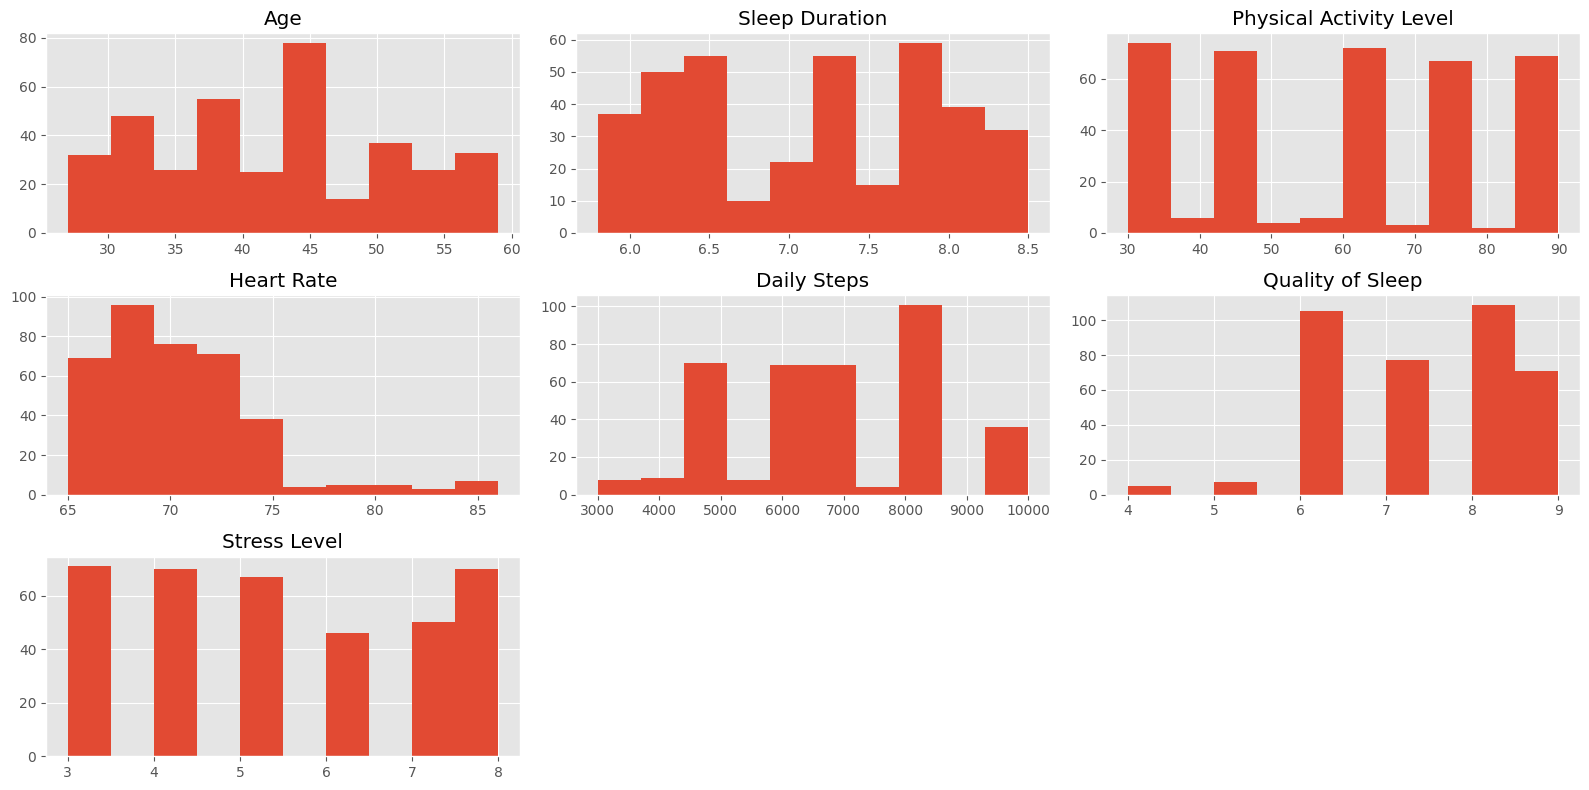

In [13]:
column =['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps',
         'Quality of Sleep', 'Stress Level']

plt.figure(figsize = (16,8))

for count, col in enumerate(column):
  plt.subplot(3, 3, count+1)
  df[col].hist()
  plt.title(col)

plt.tight_layout()
plt.show()




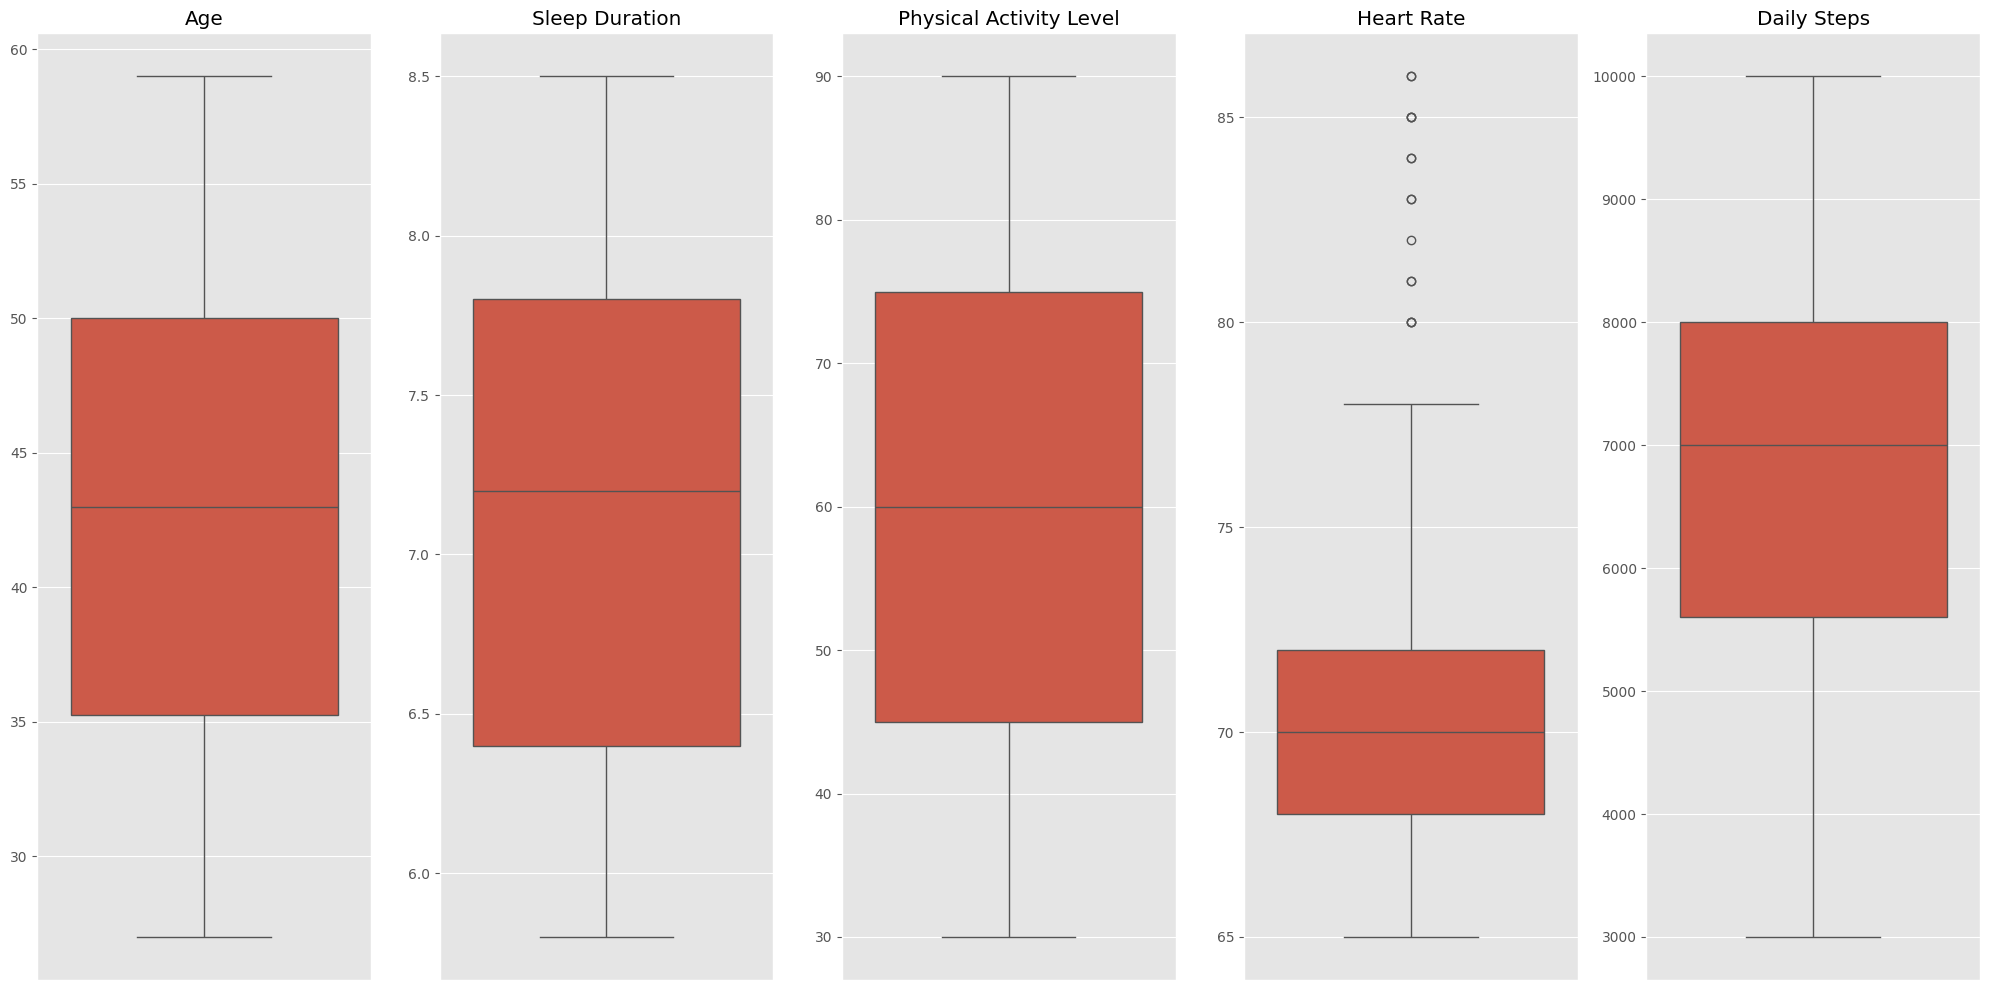

In [14]:
columns_to_plot = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']

fig, axes = plt.subplots(ncols=len(columns_to_plot), figsize=(20, 10))

for column, axis in zip(columns_to_plot, axes):
    sns.boxplot(data=df[column], ax=axis)
    axis.set_title(column)
    axis.set(xticklabels=[], xticks=[], ylabel="")

plt.tight_layout()
plt.show()

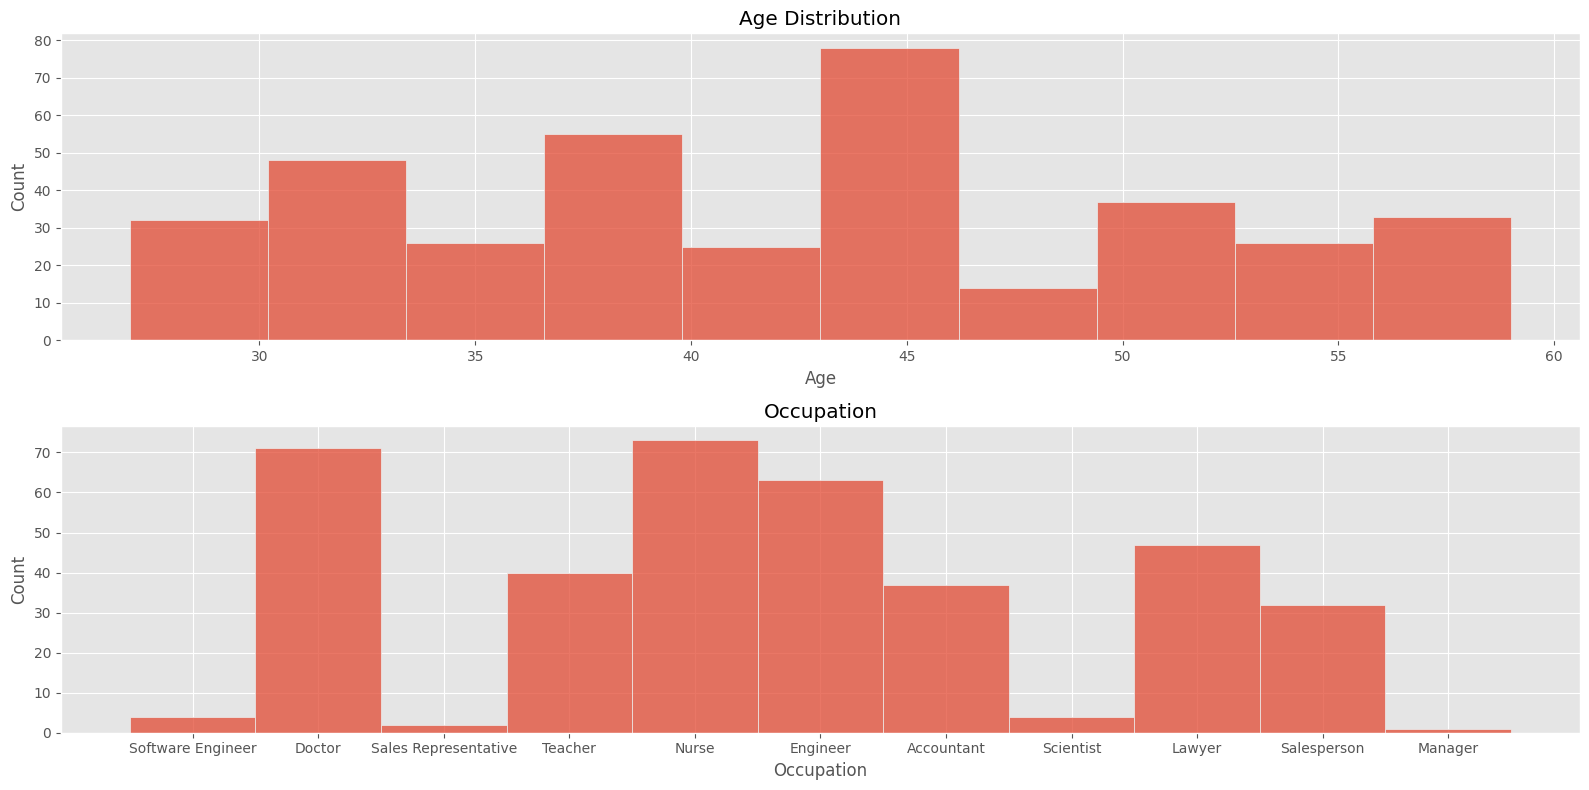

In [15]:
plt.figure(figsize = (16,8))


plt.subplot(2, 1, 1)


sns.histplot(df['Age'])
plt.title('Age Distribution')

plt.subplot(2,1,2)

sns.histplot(df['Occupation'])

plt.title("Occupation")

plt.tight_layout()
plt.show()



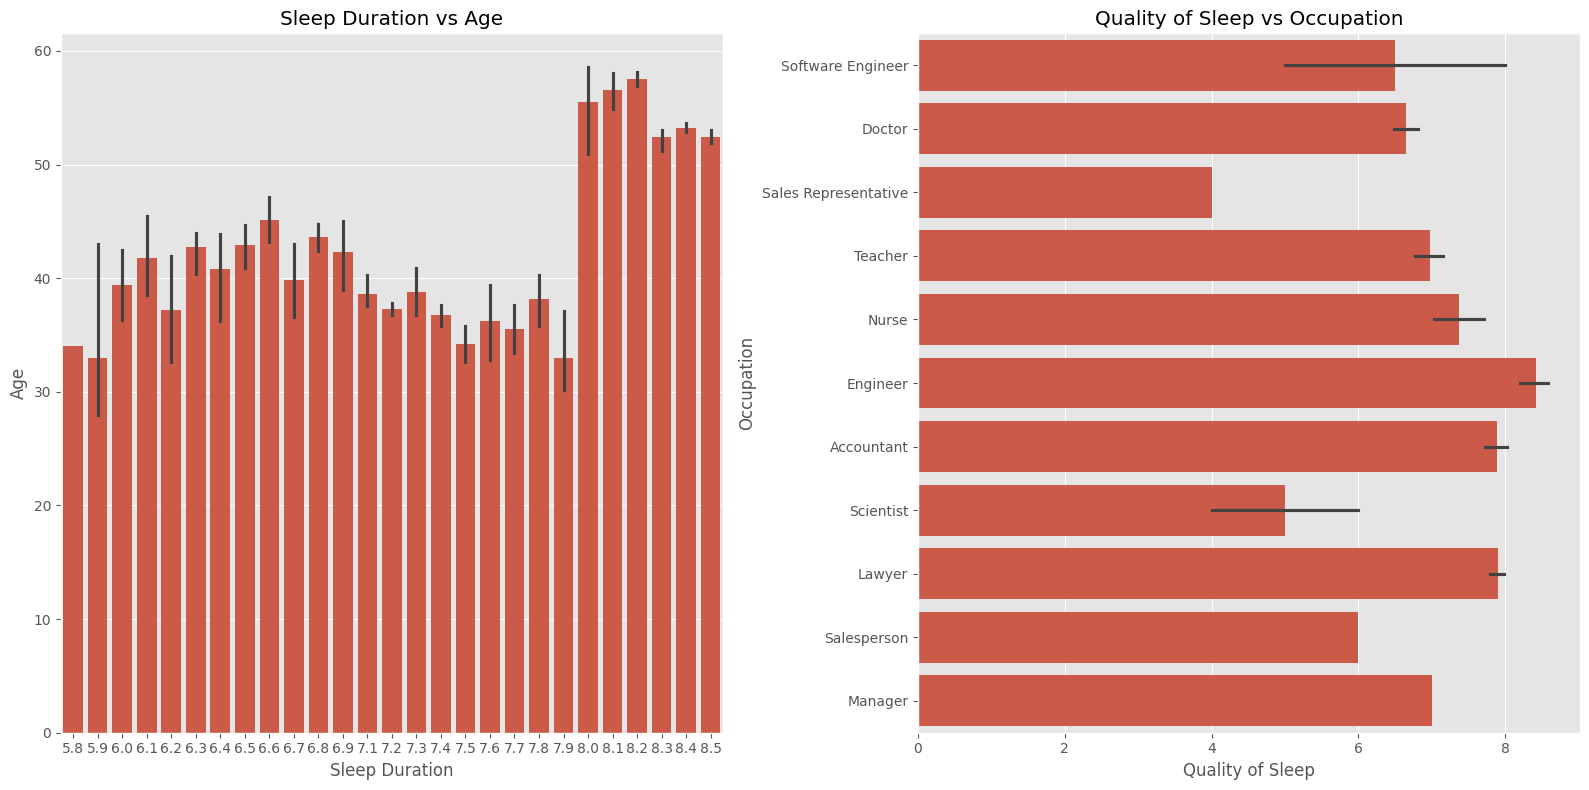

In [16]:
plt.figure(figsize = (16,8))

plt.subplot(1, 2, 1)
sns.barplot(df, x = 'Sleep Duration', y = 'Age')
plt.title("Sleep Duration vs Age")


plt.subplot(1, 2, 2)
sns.barplot(df, x = 'Quality of Sleep', y = 'Occupation')
plt.title("Quality of Sleep vs Occupation")
plt.tight_layout()
plt.show()



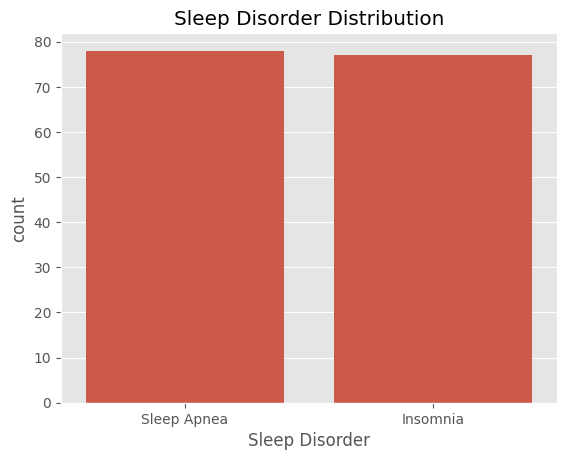

In [17]:
plt.figure()
sns.countplot(x="Sleep Disorder", data=df)
plt.title("Sleep Disorder Distribution")
plt.show()

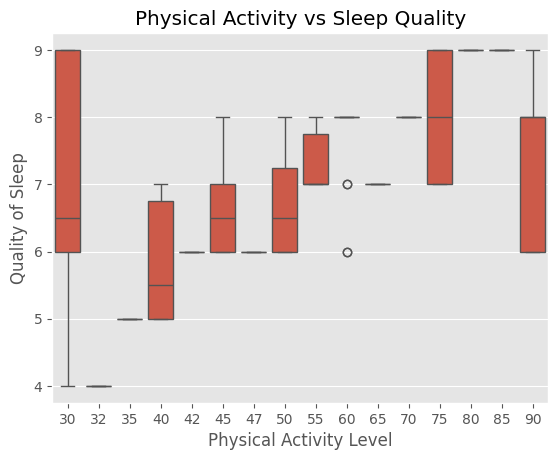

In [18]:
# phsical activitiy and sleep quality

plt.figure()
sns.boxplot(
    x="Physical Activity Level",
    y="Quality of Sleep",
    data=df
)
plt.title("Physical Activity vs Sleep Quality")
plt.show()


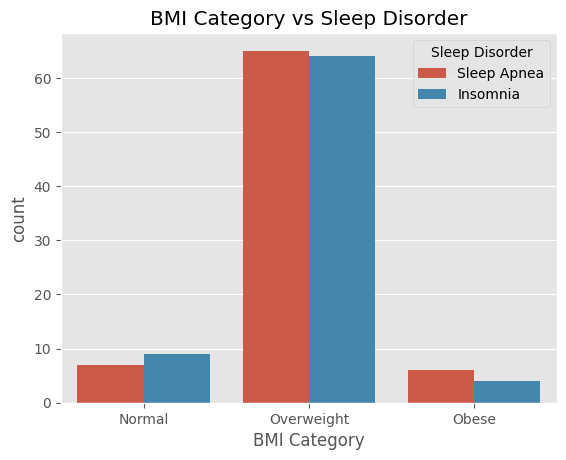

In [19]:
bmi_labels = ["Normal", "Overweight", "Obese"]

plt.figure()
sns.countplot(
    x="BMI Category",
    hue="Sleep Disorder",
    data=df
)
plt.xticks(ticks=[0, 1, 2], labels=bmi_labels)
plt.title("BMI Category vs Sleep Disorder")
plt.show()

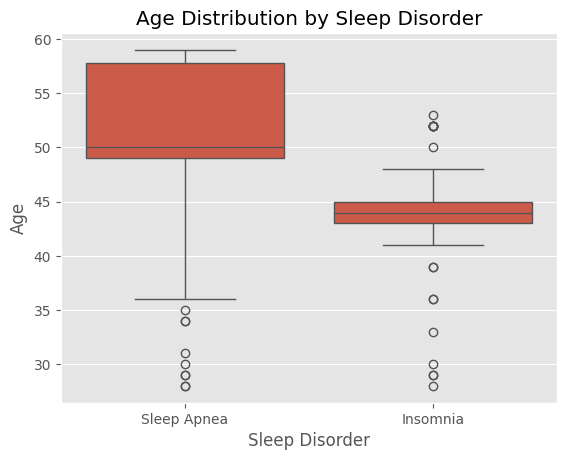

In [20]:
plt.figure()
sns.boxplot(
    x="Sleep Disorder",
    y="Age",
    data=df
)
plt.title("Age Distribution by Sleep Disorder")
plt.show()


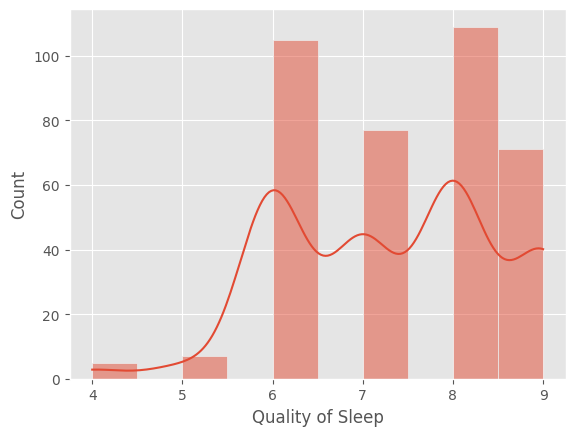

In [21]:
sns.histplot(df, x = 'Quality of Sleep', kde = True)

plt.show()

In [22]:
occupation_summary = (
    df.groupby("Occupation")
    .agg(
        avg_sleep_duration=("Sleep Duration", "mean"),
        avg_sleep_quality=("Quality of Sleep", "mean"),
        avg_stress=("Stress Level", "mean")
    )
    .sort_values("avg_sleep_quality")
)

occupation_summary


,avg_sleep_duration,avg_sleep_quality,avg_stress
Occupation,,,
Sales Representative,5.900000,4.000000,8.000000
Scientist,6.000000,5.000000,7.000000
Salesperson,6.403125,6.000000,7.000000
Software Engineer,6.750000,6.500000,6.000000
Doctor,6.970423,6.647887,6.732394
Teacher,6.690000,6.975000,4.525000
Manager,6.900000,7.000000,5.000000
Nurse,7.063014,7.369863,5.547945
Accountant,7.113514,7.891892,4.594595


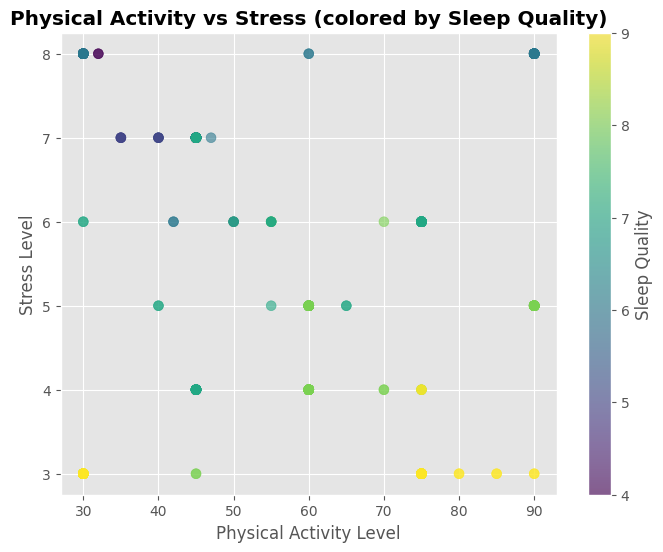

In [23]:
fig = plt.figure(figsize=(8, 6))



if 'Physical Activity Level' in df.columns and 'Stress Level' in df.columns:
    plt.scatter(df['Physical Activity Level'], df['Stress Level'], 
                alpha=0.6, s=50, c=df['Quality of Sleep'], cmap='viridis')
    plt.colorbar(label='Sleep Quality')
    plt.xlabel('Physical Activity Level')
    plt.ylabel('Stress Level')
    plt.title('Physical Activity vs Stress (colored by Sleep Quality)', fontweight='bold')

## **Feature Engineering**

Let's look at duplications, missing values, min and max


It seems like `nan` is just None. So our dataset is good and doesn't have any missing values

**Insight**

We have no missing values or outliers.
So let's label encode most of object feature. Let's have a look at those columns to know what we are dealing with

In [24]:
df['Occupation'].unique()

<ArrowStringArray>
[   'Software Engineer',               'Doctor', 'Sales Representative',
              'Teacher',                'Nurse',             'Engineer',
           'Accountant',            'Scientist',               'Lawyer',
          'Salesperson',              'Manager']
Length: 11, dtype: str

In [25]:
df['Blood Pressure'].unique()

<ArrowStringArray>
['126/83', '125/80', '140/90', '120/80', '132/87', '130/86', '117/76',
 '118/76', '128/85', '131/86', '128/84', '115/75', '135/88', '129/84',
 '130/85', '115/78', '119/77', '121/79', '125/82', '135/90', '122/80',
 '142/92', '140/95', '139/91', '118/75']
Length: 25, dtype: str

We can split `Blood Pressure` into `Systolic` and `Diastolic`

Notice we have `Normal` and `Normal weight` at the same time. statiscallly checking if they are the same or different

It looks like `gender` and `Blood Pressure` will need special care

- `gender` will convert to boolean value (turn to `int`)

The rest can be encode with `pd.get_dummies` And notice in `BMI Category` there are `Normal` and `Normal Weight` and I assume that they are the same thing so we will merge them into one


And we are also gonna make a new **dataframe** to hold some of the features that we would need later for *Research Question 2*

In [26]:
df_rq2 = df[['Person ID', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Sleep Disorder']] # to keep occupations etc. as such for RQ2

In [27]:

df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand = True).astype(int)
df['is_Male'] = (df['Gender'] == "Male").astype(int)

df = df.drop(columns = ['Blood Pressure', 'Gender'])

In [28]:
df.columns

Index(['Person ID', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Sleep Disorder', 'Systolic', 'Diastolic', 'is_Male'],
      dtype='str')

## Research Question 1


Let's set up some **correlation matrix**, the encoded one will have their own separated table underneath.

Now for *Research Question 1*, we are making to different approaches, one is to predict the `Sleep Quality` and the other is to predict the `Sleep Duration`. This is because `Sleep Quality` is a bias (subjective) feature.

In [29]:
def categorize_sleep_quality(score):
    if score < 7:
        return 1
    else:
        return 0

df["sleep_quality_bad"] = df["Quality of Sleep"].apply(categorize_sleep_quality)

df[["Quality of Sleep", "sleep_quality_bad"]].head()


,Quality of Sleep,sleep_quality_bad
0,6,1
1,6,1
2,6,1
3,4,1
4,4,1


In [30]:
class_counts = df["sleep_quality_bad"].value_counts()
class_percentages = df["sleep_quality_bad"].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": class_counts,
    "percentage (%)": class_percentages.round(2)
})




,count,percentage (%)
sleep_quality_bad,,
0,257,68.72
1,117,31.28


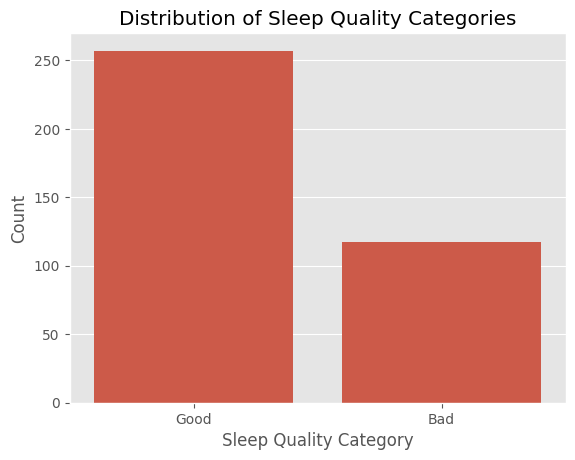

In [31]:
plt.figure()
sns.countplot(x="sleep_quality_bad", data=df)
plt.xticks(ticks=[0, 1], labels=["Good", "Bad"])
plt.title("Distribution of Sleep Quality Categories")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Count")
plt.show()

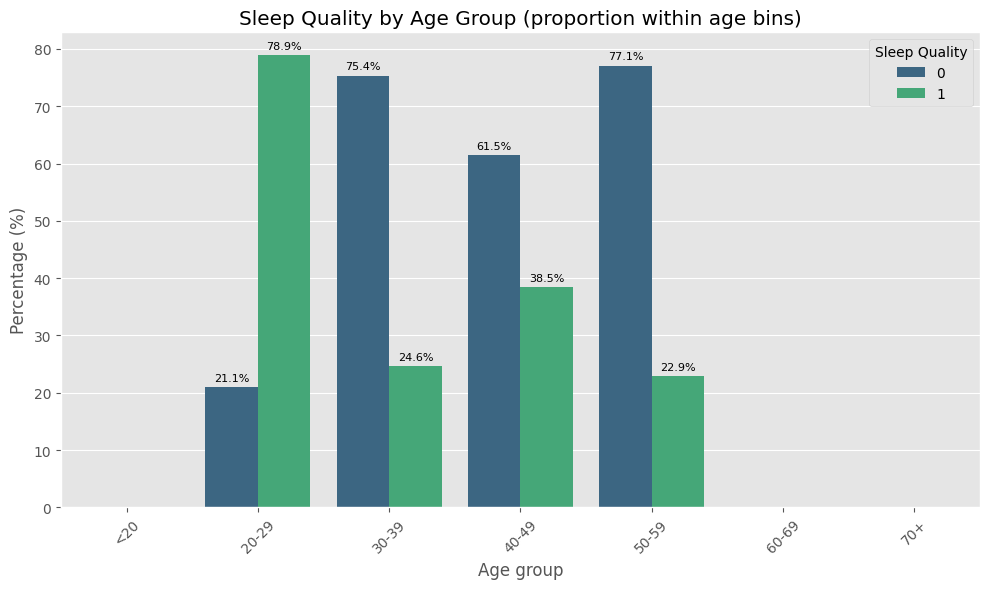

In [32]:


# Age vs Sleep quality — improved: bin ages and plot proportions
import pandas as pd
plt.figure(figsize=(10,6))

age_bins = [0,20,30,40,50,60,70,120]
age_labels = ['<20','20-29','30-39','40-49','50-59','60-69','70+']
df['age_bin'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
# compute percent distribution of sleep-quality within each age bin
age_quality = (
    df.groupby(['age_bin','sleep_quality_bad'], observed = False)
      .size()
      .reset_index(name='count')
)
age_totals = df.groupby('age_bin', observed = False).size().reset_index(name='total')
age_quality = age_quality.merge(age_totals, on='age_bin')
age_quality['pct'] = age_quality['count'] / age_quality['total'] * 100
# plot proportions per age bin
sns.barplot(
    x='age_bin',
    y='pct',
    hue='sleep_quality_bad',
    data=age_quality,
    palette='viridis',
    order=age_labels
)
plt.ylabel('Percentage (%)')
plt.xlabel('Age group')
plt.title('Sleep Quality by Age Group (proportion within age bins)')
plt.legend(title='Sleep Quality')
plt.xticks(rotation=45)
# annotate bars with percentage labels
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x()+p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0,3), textcoords='offset points')
plt.tight_layout()
plt.show()

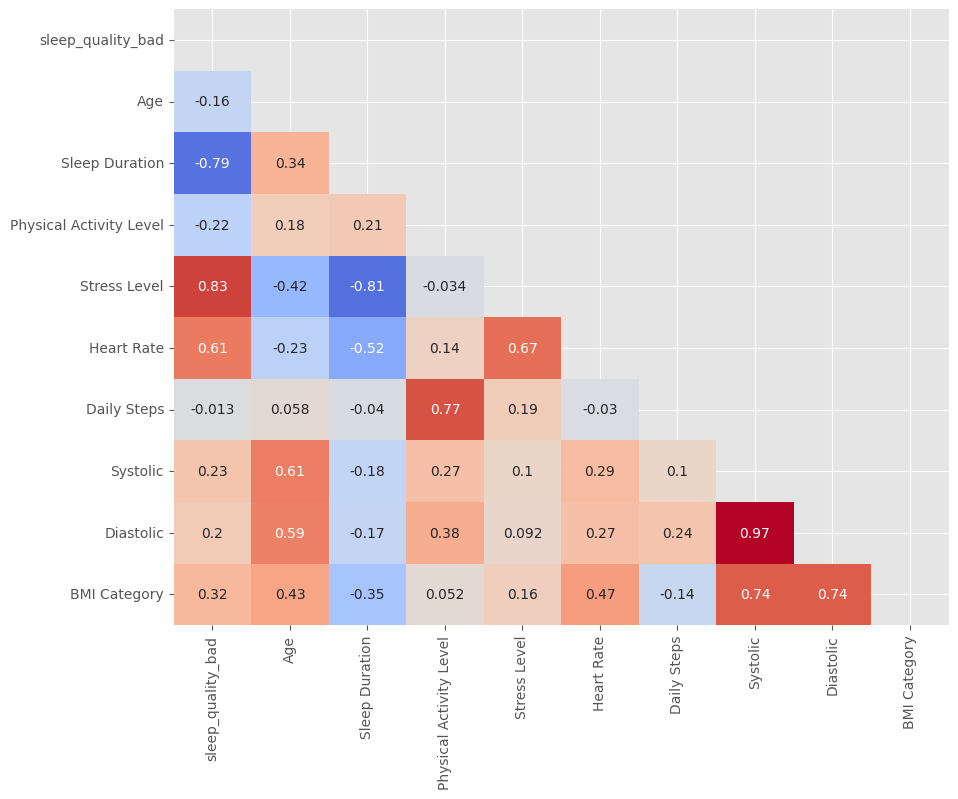

In [33]:
import numpy as np

corr_cols_1 = [
    "sleep_quality_bad",
    "Age",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic",
    "Diastolic",
    "BMI Category"
]

plt.figure(figsize=(10, 8))
corr_matrix_1 = df[corr_cols_1].corr()
mask_1 = np.triu(np.ones_like(corr_matrix_1, dtype=bool))
sns.heatmap(corr_matrix_1, mask = mask_1, cmap = 'coolwarm', 
            annot = True, center = 0, cbar = False)

plt.show()


Let's make a simple `Logistic Regression` to see what we have

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


num_feature = [
        # "Sleep Duration",
        "Physical Activity Level",
        # "Stress Level",
        "Heart Rate",
        "Daily Steps",
        "Systolic",
        # "Diastolic",
        "Age",
        "BMI Category",
        'is_Male'
    ]

cat_feature =[
    'Occupation',
    'Sleep Disorder'
]

X = df[num_feature + cat_feature]

y = df["sleep_quality_bad"]

preprocessor = ColumnTransformer(
    transformers = [
        ("scaler", StandardScaler(), num_feature),
        ('cat', OneHotEncoder(handle_unknown= 'ignore'), cat_feature)
    ]
)




In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=8,
    stratify=y
)

print(f"train shape: {X_train.shape}")
print(f"test shape: {X_test.shape}")
print('-' * 20)
print(y_train.value_counts(normalize=True), y_test.value_counts(normalize=True))

train shape: (299, 9)
test shape: (75, 9)
--------------------
sleep_quality_bad
0    0.685619
1    0.314381
Name: proportion, dtype: float64 sleep_quality_bad
0    0.693333
1    0.306667
Name: proportion, dtype: float64


In [36]:
models = {
    'log_reg' : Pipeline([
        ('preprocess', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000,
            class_weight="balanced",
            random_state=8))
    ]),
    'Random_forest': Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight="balanced",
            random_state=8
        ))
    ])
}

In [37]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=8
)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1_macro",
    "roc_auc": "roc_auc"
}

comparisons = {}

for name, model in models.items():
    model_cv = cross_validate(
        model,
        X, y,
        cv=cv,
        scoring=scoring
    )
    
    comparisons[name] = {
        "fit_time":    model_cv["fit_time"].mean(),
        "score_time":  model_cv["score_time"].mean(),
        "accuracy":    model_cv["test_accuracy"].mean(),
        "f1":          model_cv["test_f1"].mean(),
        "roc_auc":     model_cv["test_roc_auc"].mean(),
    }

# Display as a DataFrame
results_df = pd.DataFrame(comparisons).T
print(results_df)


               fit_time  score_time  accuracy        f1   roc_auc
log_reg        0.017766    0.013200  0.975964  0.973068  0.989208
Random_forest  0.378030    0.042195  0.989297  0.987511  0.998689


In [38]:
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    print(f'Report for {name}:\n\n{classification_report(y_true= y_test, y_pred= y_pred)}')

    print('===' * 20)

Report for log_reg:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        52
           1       0.96      0.96      0.96        23

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75

Report for Random_forest:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        52
           1       1.00      0.96      0.98        23

    accuracy                           0.99        75
   macro avg       0.99      0.98      0.98        75
weighted avg       0.99      0.99      0.99        75



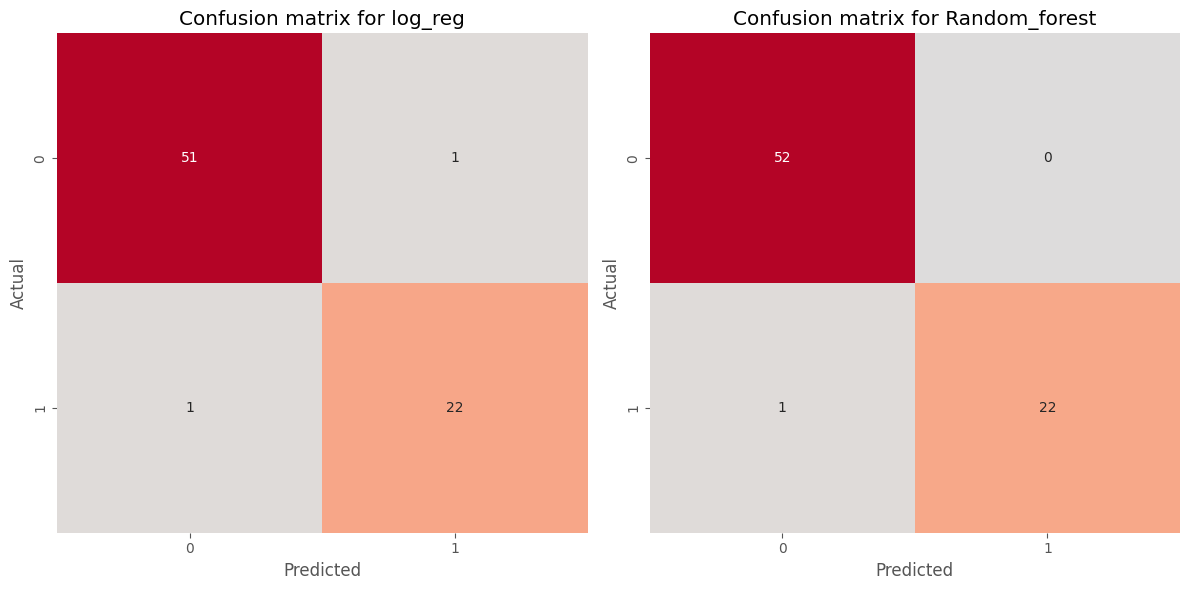

In [39]:
plt.figure(figsize=(12, 6))

for count, (name, model) in enumerate(models.items()):
    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_true= y_test, y_pred= predictions[name])
    sns.heatmap(cm, annot = True, fmt = 'd', cmap= 'coolwarm', cbar = False,
                center = 0)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion matrix for {name}')

plt.tight_layout()
plt.show()

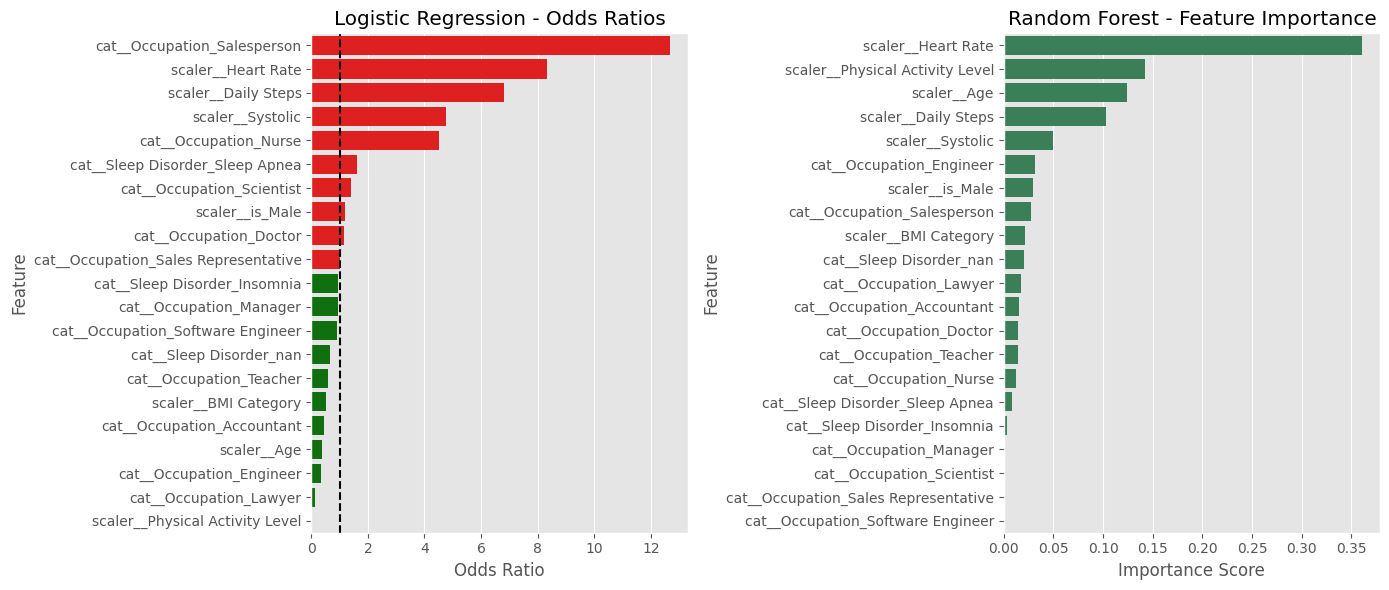

In [40]:
feature_names = models['log_reg'].named_steps['preprocess'].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log Reg Feature Imp
log_reg_model = models['log_reg'].named_steps['classifier']
odds_ratios = np.exp(log_reg_model.coef_[0])

lr_df = pd.DataFrame({
    "feature": feature_names,
    "odds_ratio": odds_ratios
}).sort_values("odds_ratio", ascending=False)

colors = ["red" if x > 1 else "green" for x in lr_df["odds_ratio"]]

sns.barplot(x="odds_ratio", y="feature", data=lr_df, ax=axes[0],
            hue="feature", palette=dict(zip(lr_df["feature"], colors)), legend=False)


axes[0].axvline(x=1, color="black", linestyle="--")
axes[0].set_title("Logistic Regression - Odds Ratios")
axes[0].set_xlabel("Odds Ratio")
axes[0].set_ylabel("Feature")

# RF Feature imp
rf_model = models['Random_forest'].named_steps['classifier']
importances = rf_model.feature_importances_

rf_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(x="importance", y="feature", data=rf_df, ax=axes[1], color="seagreen")
axes[1].set_title("Random Forest - Feature Importance")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")


plt.tight_layout()
plt.show()

In [41]:
# Bad vs Good counts and proportions by occupation
occ_counts = (
    df.groupby(["Occupation", "sleep_quality_bad"])
      .size()
      .unstack(fill_value=0)
)

# Ensure both columns exist (in case one category is missing for an occupation)
for col in [1, 0]:
    if col not in occ_counts.columns:
        occ_counts[col] = 0

occ_counts["total"] = occ_counts[1] + occ_counts[0]
occ_counts["bad_proportion"] = occ_counts[1] / occ_counts["total"]
occ_counts["good_proportion"] = occ_counts[0] / occ_counts["total"]

# Sort by proportion of Bad sleepers (highest first)
occ_counts_sorted = occ_counts.sort_values("bad_proportion", ascending=False)
occ_counts_sorted


sleep_quality_bad,0,1,total,bad_proportion,good_proportion
Occupation,,,,,
Scientist,0,4,4,1.000000,0.000000
Salesperson,0,32,32,1.000000,0.000000
Sales Representative,0,2,2,1.000000,0.000000
Nurse,36,37,73,0.506849,0.493151
Software Engineer,2,2,4,0.500000,0.500000
Doctor,38,33,71,0.464789,0.535211
Teacher,35,5,40,0.125000,0.875000
Engineer,61,2,63,0.031746,0.968254
Accountant,37,0,37,0.000000,1.000000


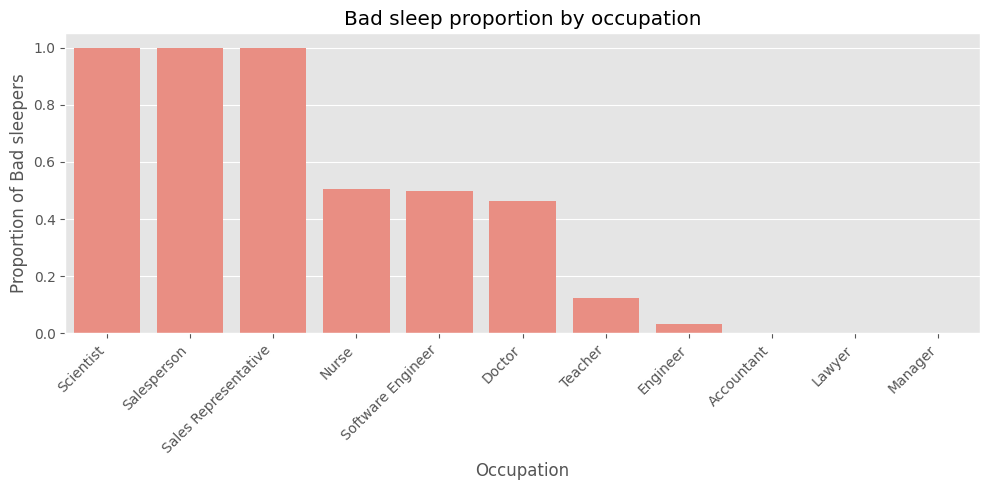

In [42]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=occ_counts_sorted.reset_index(),
    x="Occupation",
    y="bad_proportion",
    color="salmon"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of Bad sleepers")
plt.title("Bad sleep proportion by occupation")
plt.tight_layout()
plt.show()


The **accuracy** is too **good** to be **viable**

So let's try our way with a second approach, this time we will be predicting `Sleep Duration`. I am leaving out `Quality of Sleep` since that can be a case of data leakage

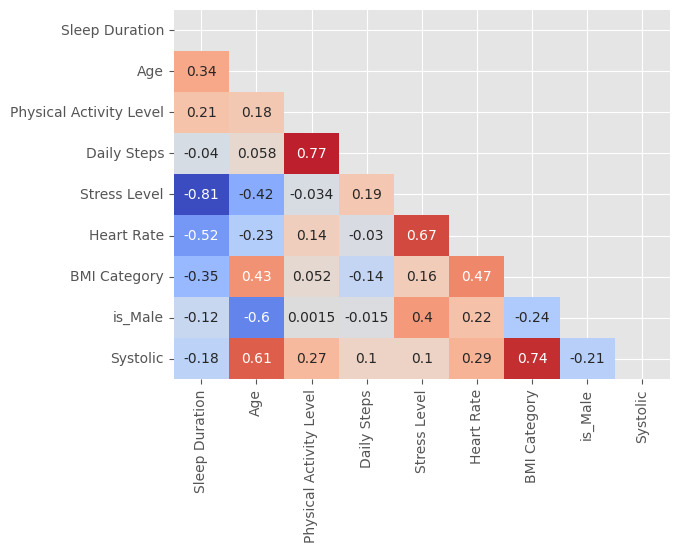

In [43]:
corr_df = df[['Sleep Duration',
              'Age',
              'Physical Activity Level',
              'Daily Steps',
              'Stress Level',
              'Heart Rate',
              'BMI Category',
              'is_Male',
              'Systolic']].copy()


matrix = corr_df.corr()

mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask = mask, cmap = 'coolwarm', annot = True, center = 0, cbar = False)

plt.show()

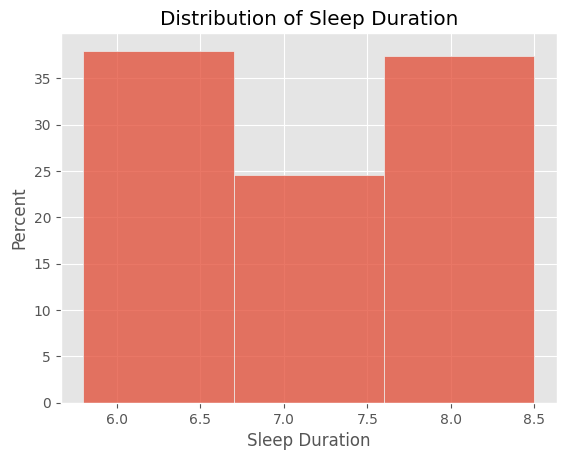

In [44]:

# Histogram
sns.histplot(df, x = "Sleep Duration", bins=3, stat = 'percent')
plt.title('Distribution of Sleep Duration')

plt.show()



In [45]:
df['Sleep Target'] = pd.qcut(df['Sleep Duration'], q= 3, labels= [0, 1, 2]).astype(int)

# Group by the new target and look at the Sleep Duration stats
ranges = df.groupby('Sleep Target')['Sleep Duration'].agg(['min', 'max', 'count'])
print(ranges)

              min  max  count
Sleep Target                 
0             5.8  6.6    142
1             6.7  7.7    126
2             7.8  8.5    106


In [46]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

num_feat = ['Age',
              'Physical Activity Level',
              'Daily Steps',
              # 'Stress Level',
              'Heart Rate',
              'BMI Category',
              'is_Male',
              'Systolic',]

cat_feat = ['Sleep Disorder',
            'Occupation']


X = df[num_feat + cat_feat]
y = df['Sleep Target']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 8, train_size= 0.8)



print(f"train shape: {X_train.shape}")
print(f"test shape: {X_test.shape}")


train shape: (299, 9)
test shape: (75, 9)


In [47]:


models = {
    'log_reg': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            multi_class='multinomial',
        ))
    ]),
    'xgb': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=200,
            objective='multi:softmax',
            num_class=3,
            random_state=8,
            eval_metric='mlogloss'
        ))
    ])
}

In [48]:
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    print(f'Report for {name}:\n\n{classification_report(y_true= y_test, y_pred= y_pred)}')

    print('===' * 20)

Report for log_reg:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        23
           1       0.74      0.81      0.77        31
           2       0.82      0.67      0.74        21

    accuracy                           0.80        75
   macro avg       0.81      0.80      0.80        75
weighted avg       0.80      0.80      0.80        75

Report for xgb:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.97      0.98        31
           2       1.00      1.00      1.00        21

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



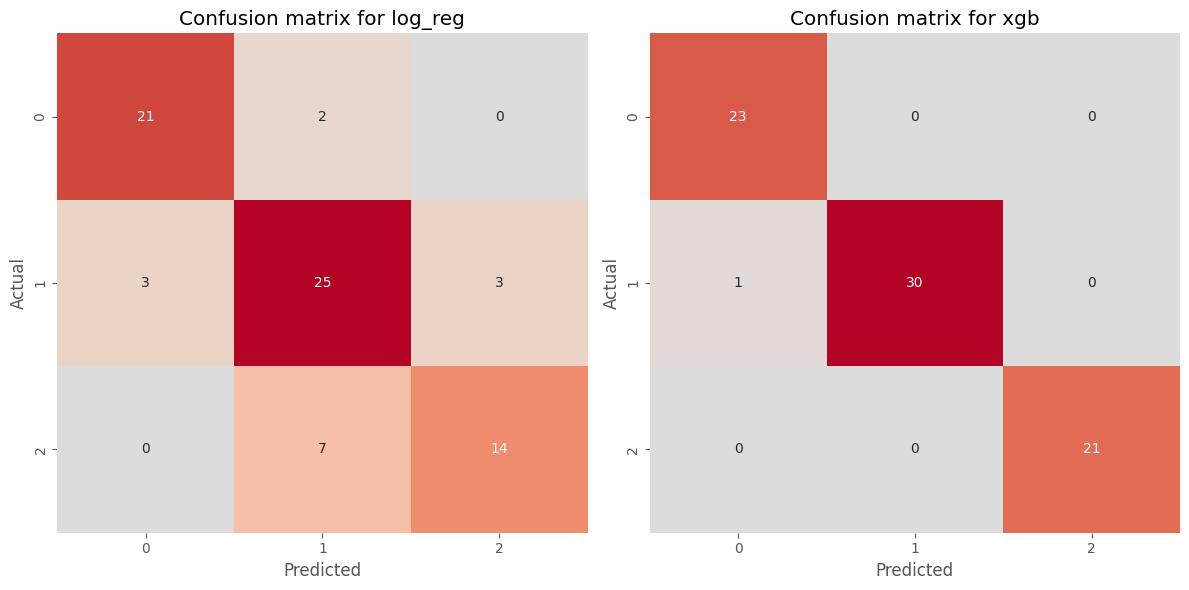

In [49]:
plt.figure(figsize=(12, 6))

for count, (name, model) in enumerate(models.items()):
    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_true= y_test, y_pred= predictions[name])
    sns.heatmap(cm, annot = True, fmt = 'd', cmap= 'coolwarm', cbar = False,
                center = 0)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion matrix for {name}')

plt.tight_layout()
plt.show()

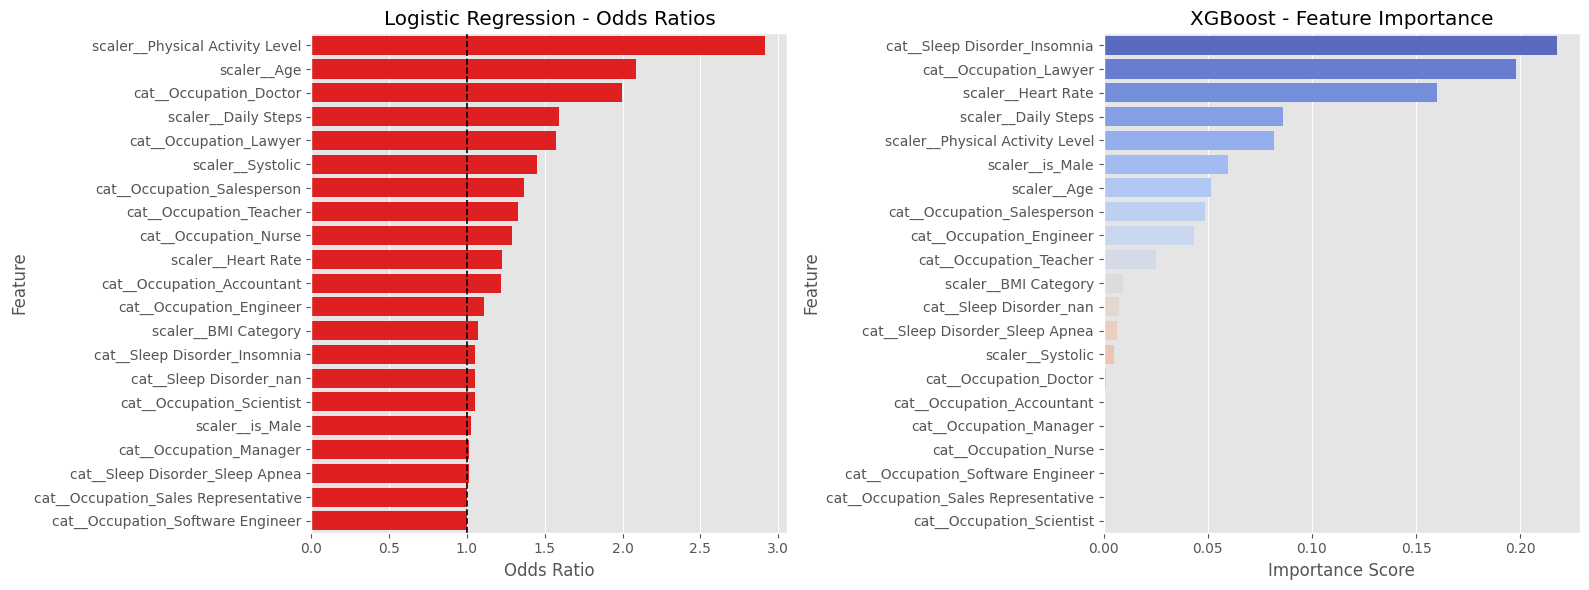

In [50]:
feature_names = models['log_reg'].named_steps['preprocessor'].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log Reg
log_reg_model = models['log_reg'].named_steps['classifier']
odds_ratios = np.exp(log_reg_model.coef_).mean(axis=0)  # mean across 3 classes

lr_df = pd.DataFrame({
    "feature": feature_names,
    "odds_ratio": odds_ratios
}).sort_values("odds_ratio", ascending=False)

colors = ["red" if x > 1 else "green" for x in lr_df["odds_ratio"]]
sns.barplot(x="odds_ratio", y="feature", data=lr_df, ax=axes[0],
            hue="feature", palette=dict(zip(lr_df["feature"], colors)), legend=False)
axes[0].axvline(x=1, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Logistic Regression - Odds Ratios")
axes[0].set_xlabel("Odds Ratio")
axes[0].set_ylabel("Feature")

# Xgboost
xgb_model = models['xgb'].named_steps['classifier']
importances = xgb_model.feature_importances_

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1],
            hue="feature", palette="coolwarm", legend=False)
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [51]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression


num_feature = [
        "Physical Activity Level",
        # "Stress Level",
        "Heart Rate",
        "Daily Steps",
        "Systolic",
        # "Diastolic",
        "Age",
        "BMI Category",
        'is_Male'
    ]

cat_feature =[
    'Occupation',
    'Sleep Disorder'
]

X = df[num_feature + cat_feature]
y = df['Sleep Duration']



X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 8, train_size= 0.8)


print(f"train shape: {X_train.shape}")
print(f"test shape: {X_test.shape}")


train shape: (299, 9)
test shape: (75, 9)


In [52]:


models = {
    'lin_reg': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression(
        ))
    ]),
    'xgb': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
    n_estimators=200,
    random_state = 8
    ))
    ])
}

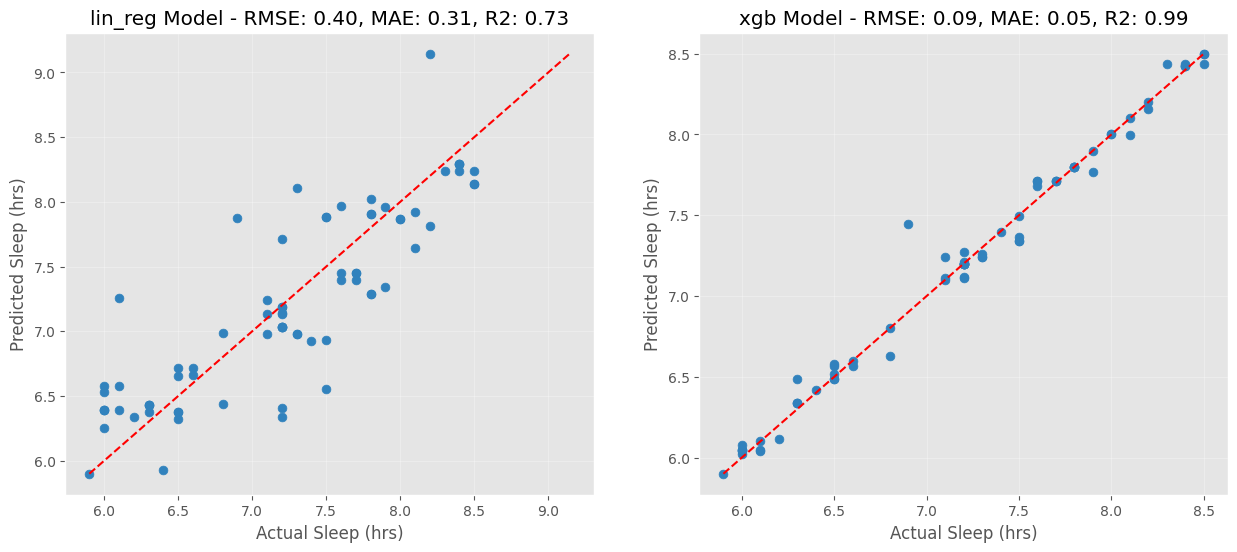

In [53]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

plt.figure(figsize= (15 ,6))
for count, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2= r2_score(y_test, y_pred)


    plt.subplot(1 , 2, count + 1)

    plt.scatter(y_test, y_pred , color='#3182bd', s=40)

    # 45-degree reference line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel('Actual Sleep (hrs)')
    plt.ylabel('Predicted Sleep (hrs)')
    plt.title(f'{name} Model - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')
    plt.grid(alpha=0.3)



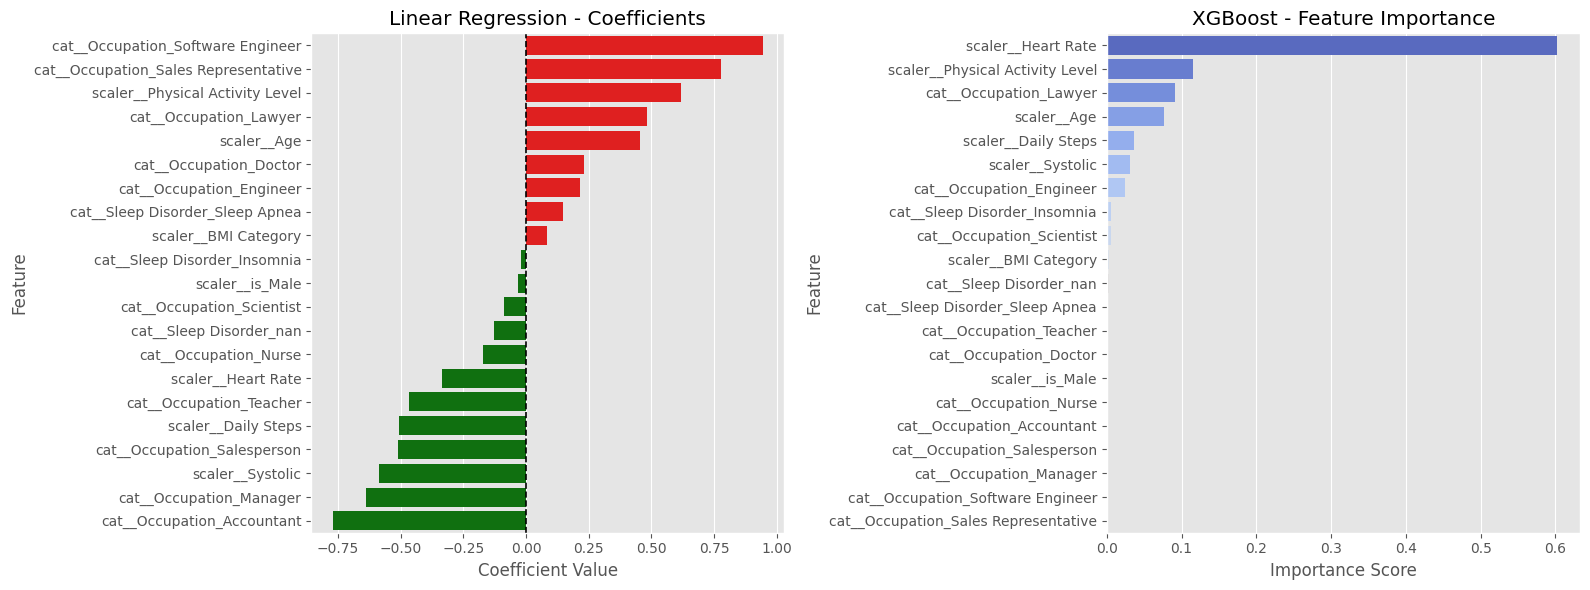

In [54]:
feature_names = models['lin_reg'].named_steps['preprocessor'].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


lr_model = models['lin_reg'].named_steps['model']
coefficients = lr_model.coef_  

lr_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

colors = ["red" if x > 0 else "green" for x in lr_df["coefficient"]]
sns.barplot(x="coefficient", y="feature", data=lr_df, ax=axes[0],
            hue="feature", palette=dict(zip(lr_df["feature"], colors)), legend=False)
axes[0].axvline(x=0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Linear Regression - Coefficients")
axes[0].set_xlabel("Coefficient Value")
axes[0].set_ylabel("Feature")

# Xgboost
xgb_model = models['xgb'].named_steps['model']
importances = xgb_model.feature_importances_

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1],
            hue="feature", palette="coolwarm", legend=False)
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

## Reseach Question 2

### High stress occupations vs. Sleep quality
The stress-level of each occupation is scored based on the O*NET database: https://www.onetonline.org/

In [55]:
job_stress = {
    'Software Engineer': 42,
    'Doctor': 80,
    'Sales Representative': 54,
    'Teacher': 70,
    'Nurse':74,
    'Engineer':41,
    'Accountant':46,
    'Scientist':35,
    'Lawyer':76,
    'Salesperson':39,
    'Manager':57
}
df_rq2['Occupation Stress'] = df_rq2['Occupation'].map(job_stress)
df_rq2

,Person ID,Occupation,Sleep Duration,Quality of Sleep,Stress Level,Sleep Disorder,Occupation Stress
0,1,Software Engineer,6.1,6,6,NaN,42
1,2,Doctor,6.2,6,8,NaN,80
2,3,Doctor,6.2,6,8,NaN,80
3,4,Sales Representative,5.9,4,8,Sleep Apnea,54
4,5,Sales Representative,5.9,4,8,Sleep Apnea,54
...,...,...,...,...,...,...,...
369,370,Nurse,8.1,9,3,Sleep Apnea,74
370,371,Nurse,8.0,9,3,Sleep Apnea,74
371,372,Nurse,8.1,9,3,Sleep Apnea,74
372,373,Nurse,8.1,9,3,Sleep Apnea,74


Occupation Stress vs. Quality of Sleep

In [56]:
corr_coeff = df_rq2['Quality of Sleep'].corr(df_rq2['Occupation Stress'])
corr_coeff

np.float64(-0.13257706989462437)

Occupation Stress vs. Sleep Duration

In [57]:
corr_coeff = df_rq2['Sleep Duration'].corr(df_rq2['Occupation Stress'])
corr_coeff

np.float64(-0.12827975478566944)

Occupation Stress vs Perceived Stress Level

In [58]:
corr_coeff = df_rq2['Stress Level'].corr(df_rq2['Occupation Stress'])
corr_coeff

np.float64(0.21479038804565856)

Stress Level vs Quality of Sleep

In [59]:
corr_coeff = df_rq2['Quality of Sleep'].corr(df_rq2['Stress Level'])
corr_coeff

np.float64(-0.8987520310040426)

Stress Level vs Sleep Duration

In [60]:
corr_coeff = df_rq2['Sleep Duration'].corr(df_rq2['Stress Level'])
corr_coeff

np.float64(-0.8110230278940443)

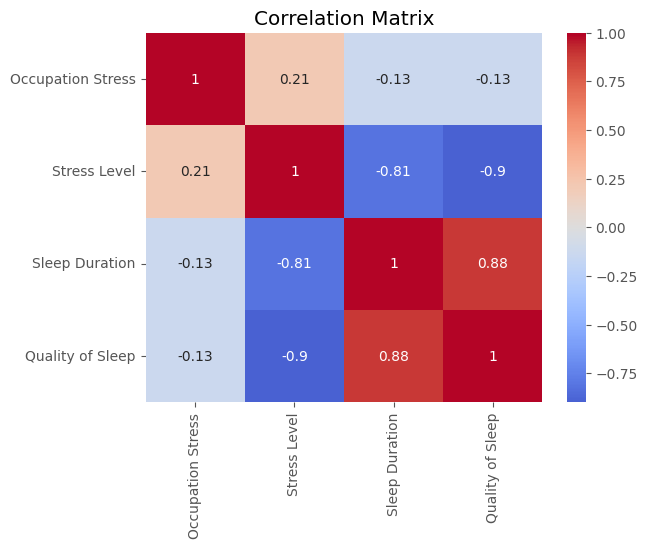

In [61]:
corr = df_rq2[['Occupation Stress',
               'Stress Level',
               'Sleep Duration',
               'Quality of Sleep']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

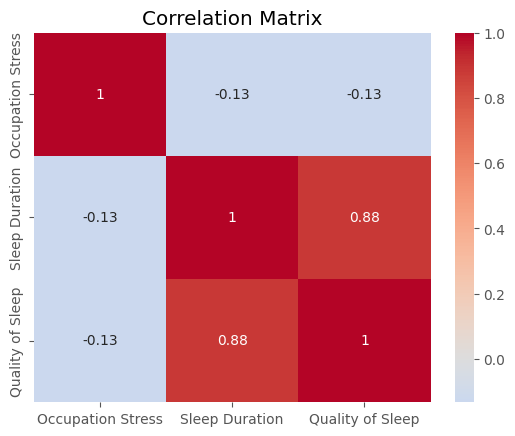

In [62]:
corr = df_rq2[['Occupation Stress',
               'Sleep Duration',
               'Quality of Sleep']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

### Short overview of the results of RQ2 - correlation analysis

So as in the correlation matrix in the preprocessing phase, it can be seen that perceived stress level has a high negative correlation with sleep quality (-0.9) and duration (-0.81). However, this was not the RQ2, this was just as a reminder.

The actual research question was to see how different levels of occupational stress affects sleep. For this, I (Kata) identified stress levels for the occupations from a (US) government-developed database that is frequently used in peer-reviewed research (O*NET). Here the stress level is from 0-100. Some occupations are likely to cover several more specific occupations, so for them I took a couple different and then took the mean of stress. Here are the specific occupation names of which the stress levels were taken from (for transparency):

    'Software Engineer': software developer

    'Doctor': general practicioner

    'Sales Representative': Sales Representatives of Services, Except Advertising, Insurance, Financial Services, and Travel

    'Teacher': middle school teacher

    'Nurse': registered nurses

    'Engineer': mean of: civil engineers (stress level 48), mechanical engineering technologists and technicians (34), and  aerospace engineers (42)

    'Accountant': accountants and auditors

    'Scientist': mean of: physicist (32), biologist (32), chemist (41), bioinformatics scientist (37), material scientist (36), computer and information research scientist (32)

    'Lawyer': lawyers

    'Salesperson': retail salespersons

    'Manager': mean of: property, real estate and community association managers (60), information technology project managers (69), administrative services managers (43)


Now looking at how occupational stress affects sleep quality and duration, there is slight negative correlation with both of them (~ -0.13). This is surprisingly low imo. Out of curiosity, I wanted to see how the occupation stress correlates with perceived stress. There is slight positive correlation (0.21), but this, as well, is surprisingly low. This suggests that occupational stress is only a small part of overall stress, not likely to be the major influencer. Other aspects clearly have major effect on overall perceived stress. It is logical that overall stress has a significant effect on sleep.

## RQ 3 - Clustering

Now let's pick out some features to see how about our clustering task.

I picked these since they are not within the *targeting features* (I want to use clustering to find out about `Sleep Illnes`, `Sleep Duration`, `Occupation`)

In [63]:
features_to_cluster = [ 'Age', 'Physical Activity Level', 'Stress Level',
                       'Heart Rate', 'BMI Category']

scaler = StandardScaler().set_output(transform="pandas")


X_cluster = scaler.fit_transform(df[features_to_cluster])

X_cluster.head(5)


,Age,Physical Activity Level,Stress Level,Heart Rate,BMI Category
0,-1.753096,-0.825418,0.347021,1.654719,1.004126
1,-1.637643,0.039844,1.475592,1.170474,-0.818899
2,-1.637643,0.039844,1.475592,1.170474,-0.818899
3,-1.637643,-1.402260,1.475592,3.591698,2.827150
4,-1.637643,-1.402260,1.475592,3.591698,2.827150


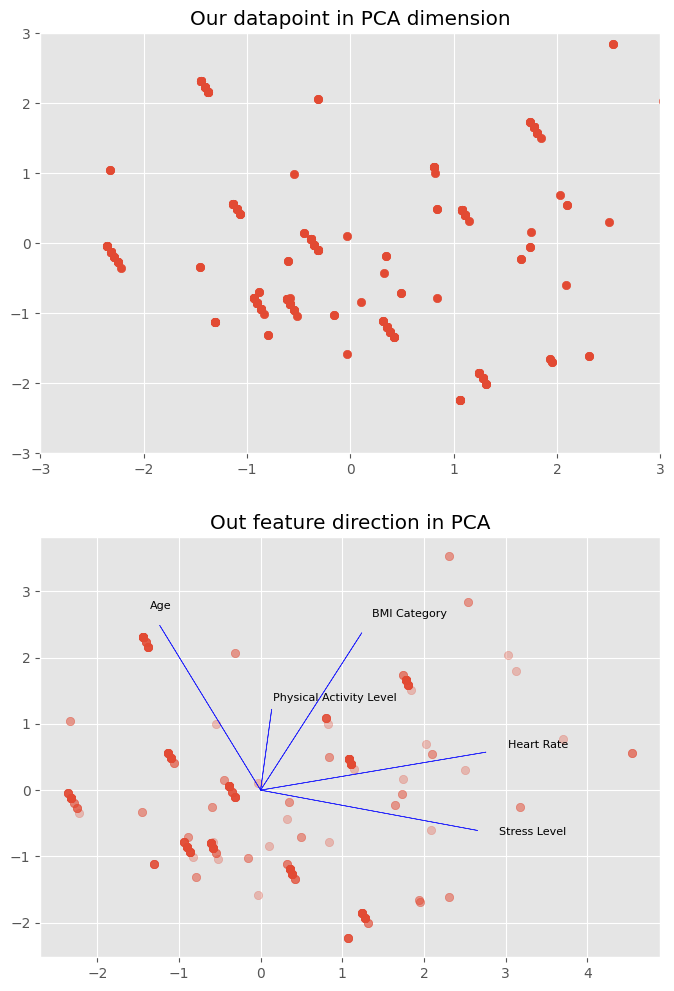

In [64]:
from sklearn.decomposition import PCA


# Make graph bigger to see
scale_factor = 3

pca = PCA(n_components= 2).set_output(transform="pandas")

pca_data = pca.fit_transform(X_cluster)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize= (8 , 12))
plt.subplot(2, 1, 1)

plt.scatter(pca_data.iloc[:, 0], pca_data.iloc[:, 1])
plt.title("Our datapoint in PCA dimension")

plt.xlim(-scale_factor, scale_factor)
plt.ylim(-scale_factor, scale_factor)

plt.subplot(2, 1, 2)
plt.scatter(pca_data.iloc[:, 0], pca_data.iloc[:, 1], alpha = 0.3)

for i, feature in enumerate(features_to_cluster):
    x_val = loadings[i, 0] * scale_factor
    y_val = loadings[i, 1] * scale_factor
    plt.arrow(0, 0, x_val, y_val,
              color = 'blue', alpha = 0.8)

    plt.text(x_val * 1.1, y_val * 1.1, feature, color='black', fontsize=8)



plt.title("Out feature direction in PCA")
plt.show()

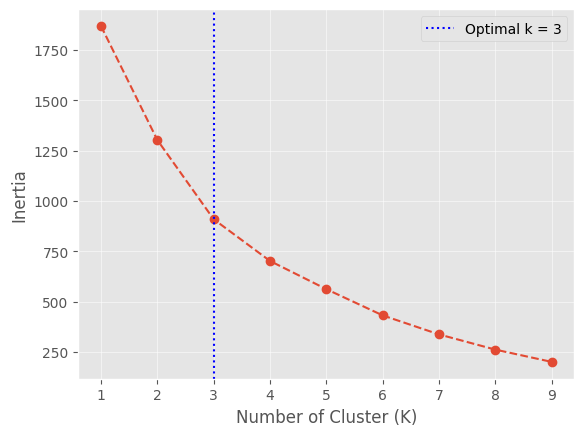

In [65]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters= k, random_state= 8, n_init= 10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)


kl = KneeLocator(K_range, inertia, curve= 'convex', direction= 'decreasing')
optimal_k = kl.elbow

plt.plot(K_range, inertia, marker = 'o', linestyle = '--')
plt.axvline(optimal_k, color = 'blue', linestyle = ':',
             label= f"Optimal k = {optimal_k}")

plt.xlabel('Number of Cluster (K)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(alpha = 0.5)

plt.show()


In [66]:

kmeans_3 = KMeans(n_clusters=3, random_state=8, n_init=10)
df['Cluster'] = kmeans_3.fit_predict(X_cluster).astype(int)

profile = df.groupby('Cluster')[features_to_cluster].mean()
print("--- 3 Clusters Profile ---")
print(profile)

--- 3 Clusters Profile ---
               Age  Physical Activity Level  Stress Level  Heart Rate  \
Cluster                                                                 
0        52.178947                51.315789      3.357895   66.157895   
1        44.642105                61.031579      7.136842   75.031579   
2        35.755435                62.266304      5.527174   69.722826   

         BMI Category  
Cluster                
0            0.642105  
1            1.105263  
2            0.010870  


### Cluster Behavioral Profiles

* **Cluster 0: Low-Strain Mature Adults**
  * *Key trait:* Low `stress`, high `age`

* **Cluster 1: High-Strain Adults**
  * *Key trait:* High stress, middle `age`, high physical performance

* **Cluster 2: Early Youth**
  * *Key trait:* High physical performance and optimal body composition, middle `stress`


In [67]:

cluster_map = {
    0: 'Chill Seniors',
    1: 'Midlife',
    2: 'Early Youth'
}

df['Cluster_Profile'] = df['Cluster'].map(cluster_map)
print(df['Cluster_Profile'].value_counts())

Cluster_Profile
Early Youth      184
Midlife           95
Chill Seniors     95
Name: count, dtype: int64


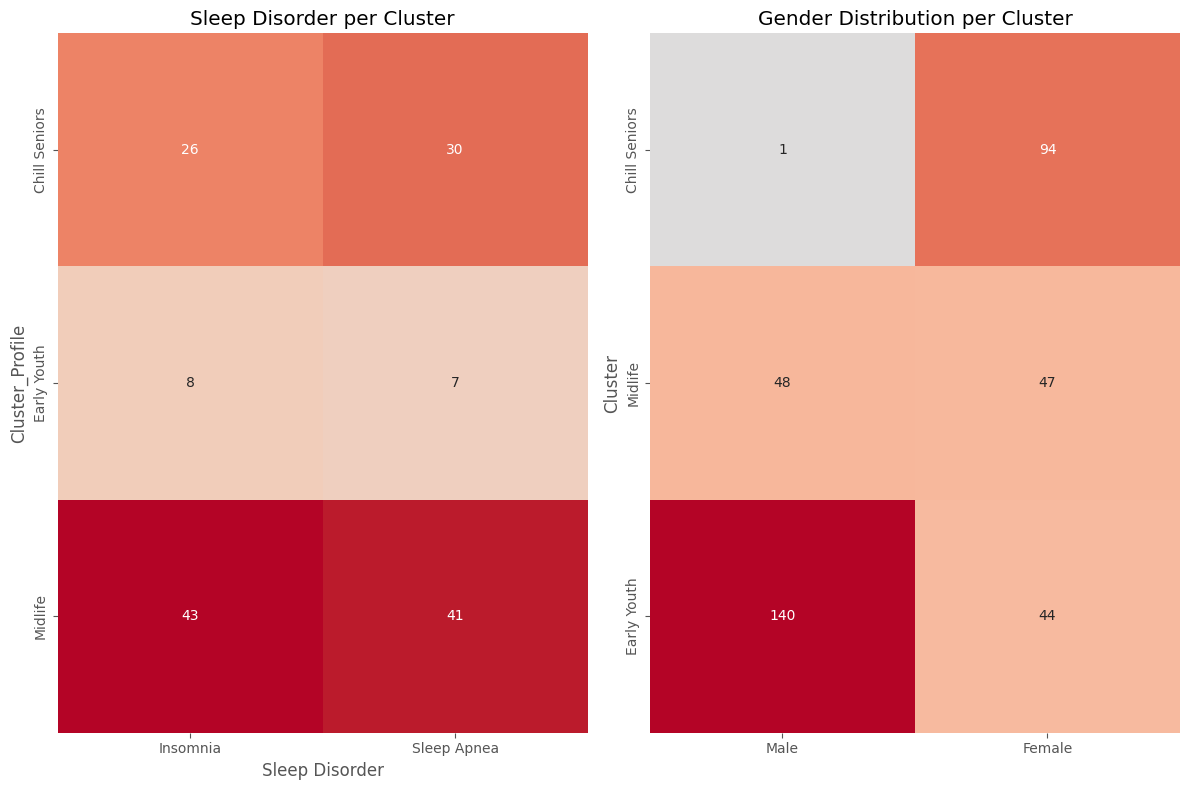

In [68]:
# Sleep Disorder per Cluster
cluster_disorders = pd.crosstab(df['Cluster_Profile'], df['Sleep Disorder'])

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
sns.heatmap(cluster_disorders, cmap='coolwarm', center=0, annot=True, fmt='d', cbar=False)
plt.title("Sleep Disorder per Cluster")

# Gender per Cluster — keep original is_Male logic
plt.subplot(1, 2, 2)
counts = df.groupby('Cluster')['is_Male'].agg(['count', 'sum'])
counts.columns = ['Total', 'Male']
counts['Female'] = counts['Total'] - counts['Male']
plot_data = counts[['Male', 'Female']]
plot_data.index = plot_data.index.map(cluster_map)

sns.heatmap(plot_data, cmap='coolwarm', annot=True, center=0, fmt='d', cbar=False)
plt.title('Gender Distribution per Cluster')
plt.tight_layout()
plt.show()

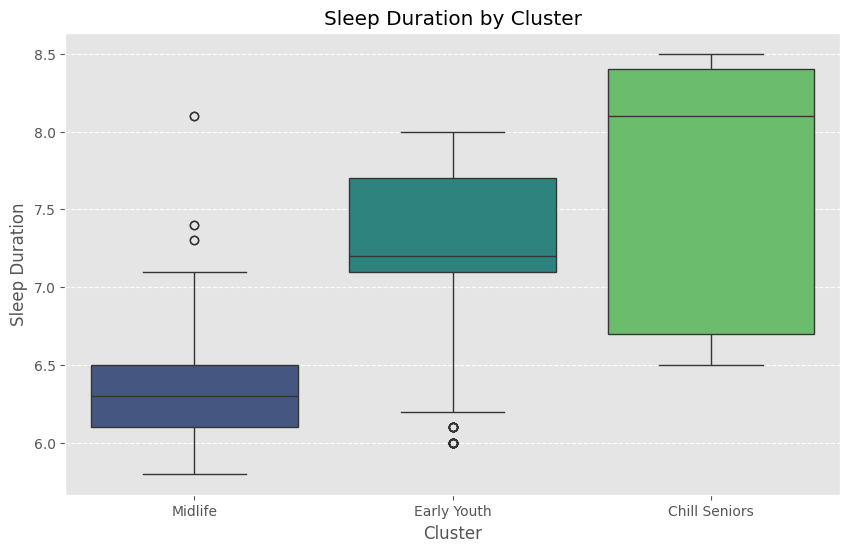

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cluster_Profile', y='Sleep Duration', palette='viridis')
plt.xlabel("Cluster")
plt.ylabel("Sleep Duration")
plt.title("Sleep Duration by Cluster")
plt.grid(axis='y', linestyle='--')
plt.show()

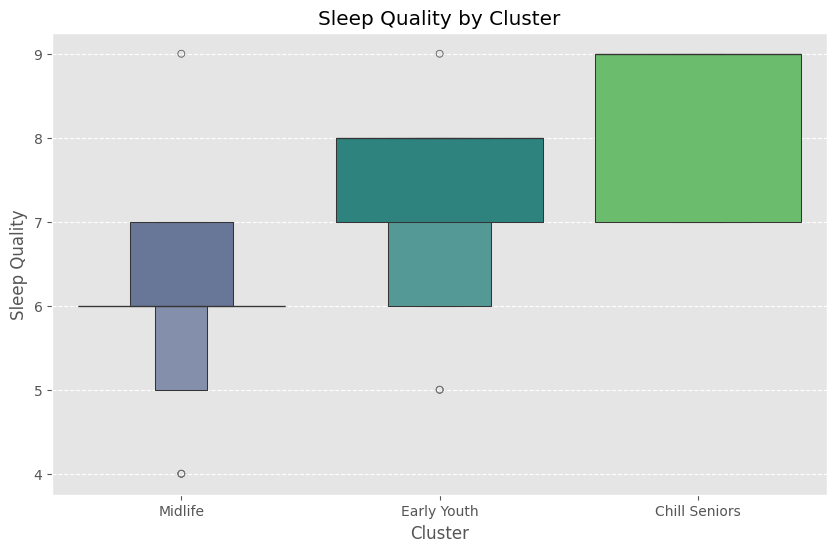

In [74]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x='Cluster_Profile', y='Quality of Sleep', palette='viridis')
plt.xlabel("Cluster")
plt.ylabel("Sleep Quality")
plt.title("Sleep Quality by Cluster")
plt.grid(axis='y', linestyle='--')
plt.show()

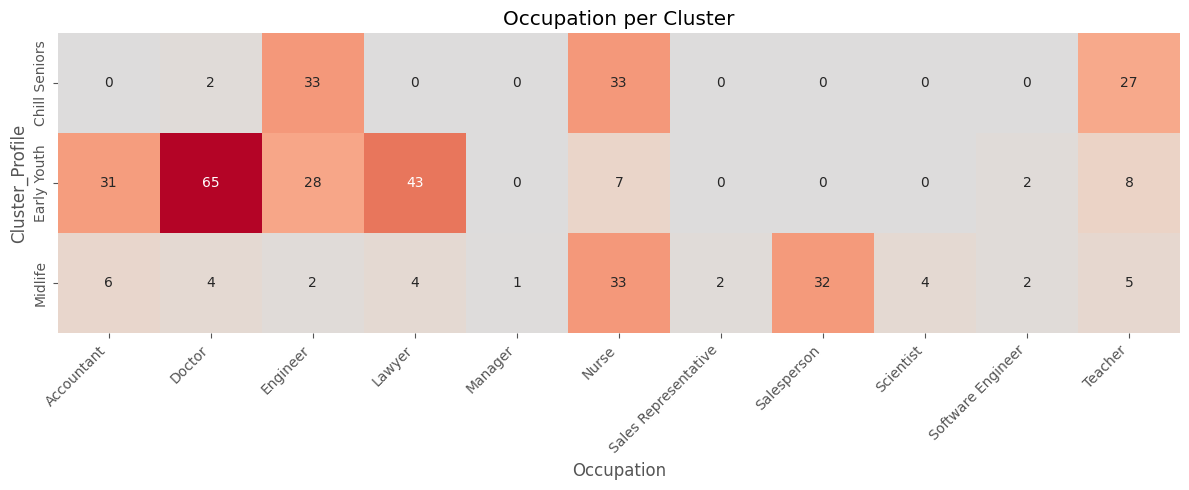

In [70]:
occupation_counts = pd.crosstab(df['Cluster_Profile'], df['Occupation'])

plt.figure(figsize=(12, 5))
sns.heatmap(occupation_counts, cmap='coolwarm', center=0, annot=True, fmt='d', cbar=False)
plt.title("Occupation per Cluster")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

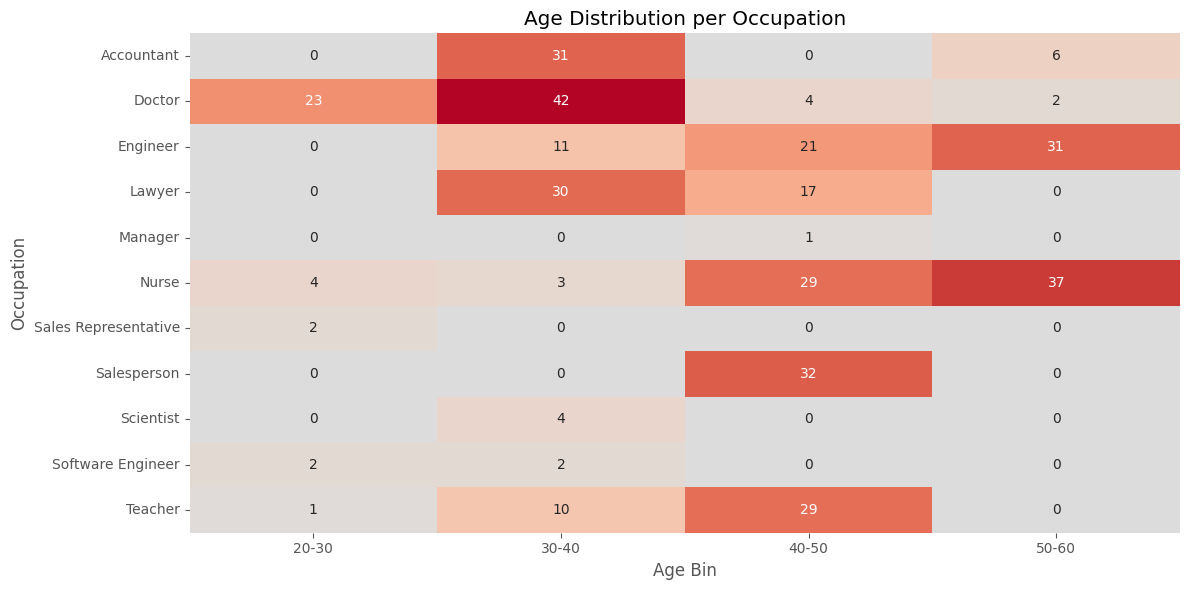

In [71]:
# Create age bins
df['Age Bin'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-30', '30-40', '40-50', '50-60'])

# Crosstab occupation vs age bin
age_occupation = pd.crosstab(df['Occupation'], df['Age Bin'])

plt.figure(figsize=(12, 6))
sns.heatmap(age_occupation, cmap='coolwarm', center=0, annot=True, fmt='d', cbar=False)
plt.title("Age Distribution per Occupation")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Cluster Behavioral Profiles

**Cluster 0: Chill Seniors** (n=95)
- Oldest group (Age ~52), lowest stress (3.4), lowest heart rate (66)
- Lowest physical activity (51) but slightly overweight BMI (0.64)
- Best sleep duration (8.4hrs) and highest sleep quality (9.0)
- Almost entirely Female (1 Male, 94 Female)
- Decently high rates of Sleep Apnea (30) and Insomnia (26) — despite best sleep quality,
  suggesting disorders are managed or compensated by age-related sleep patterns

**Cluster 1: Midlife** (n=95)
- Middle-aged (44), highest stress (7.1), highest heart rate (75)
- Moderate activity (61), overweight BMI (1.1)
- Poor sleep duration (6.3hrs)
- Balanced gender (48M, 47F)
- Highest sleep disorder rates — Insomnia (43) and Sleep Apnea (41)
- Most at-risk cluster overall

**Cluster 2: Early Youth** (n=184)
- Youngest group (Age ~36), moderate stress (5.5), normal BMI (0.01)
- Highest physical activity (62), healthy heart rate (70)
- Moderate sleep duration (7.7hrs)
- Heavily Male (140M, 44F)
- Lowest sleep disorder rates (Insomnia: 8, Sleep Apnea: 7)

### Key Takeaways
- Sleep quality improves with age and lower stress (Chill Seniors sleep best)
- High stress + middle age = worst sleep disorders (Midlife cluster)
- Youth and fitness alone don't guarantee good sleep (Early Youth moderate sleep despite best BMI)
- Gender is heavily skewed — Early Youth is male-dominated, Chill Seniors almost entirely female

### Limitations
- **Occupation is confounded by age** — occupation distributions are not even across age 
  groups, so cluster differences in occupation reflect age skew rather than 
  occupation-specific sleep patterns. Occupation should not be interpreted as a 
  cluster driver.
- **Gender imbalance** — the heavy skew (Early Youth nearly all Male, Chill Seniors nearly 
  all Female) makes it difficult to separate gender effects from age and stress effects.
- **Cluster labels are interpretive** — KMeans assigns arbitrary numeric labels; the 
  descriptive names (Chill Seniors, Midlife, Early Youth) are human-assigned based on 
  mean feature values and may oversimplify within-cluster variation.
- **BMI encoding** — BMI Category was ordinally encoded (0=Normal, 1=Overweight, 2=Obese), 
  so mean BMI values (e.g. 0.01 for Early Youth) should be read as "nearly all Normal" 
  rather than a continuous measurement.